In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score,recall_score,f1_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

In [1]:
 #Read the dataset 
data=pd.read_csv('sl_data.csv')
print(data.shape)
#print(data.dtypes)

<IPython.core.display.Javascript object>

(1008, 32)


In [3]:
#Calculate five-point summary for numerical variables 
numeric_data=data.select_dtypes(include='number')
numeric_data.describe()

,Patient_ID,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F21,F22,F23,F24,F25,F26,F27,F28,F29,F30
count,1008.000000,1007.000000,1007.000000,1006.000000,1008.000000,1006.000000,1008.000000,1007.000000,1007.000000,1007.000000,...,1008.000000,1008.000000,1008.000000,1008.000000,1008.000000,1008.000000,1008.000000,1008.000000,1008.000000,1008.000000
mean,504.419643,12.559906,14.570835,100.306961,752.996970,0.099885,0.077377,0.050885,0.033116,0.227398,...,16.972966,25.936423,125.897018,551.940076,0.152804,0.276515,0.184987,0.089401,0.263358,0.074210
std,290.992029,3.886917,4.148864,28.998768,380.141070,0.020030,0.042208,0.057187,0.035179,0.041402,...,6.264067,6.674752,48.061970,458.210733,0.033373,0.194750,0.160285,0.064984,0.069820,0.019388
min,1.000000,5.753360,6.407277,38.728787,93.157800,0.050752,0.000202,0.000049,0.000019,0.109000,...,6.691088,8.792066,37.237149,1.886849,0.077512,0.000165,0.000333,0.000186,0.075547,0.026947
25%,252.750000,9.778168,11.453264,80.076676,501.263509,0.085531,0.046498,0.013438,0.007599,0.200184,...,12.572423,21.282321,90.948109,246.335394,0.129968,0.142274,0.059360,0.034905,0.212662,0.060734
50%,504.500000,11.906741,14.019957,96.948771,656.942181,0.099214,0.072006,0.028263,0.018810,0.222983,...,15.376920,25.590731,113.419386,438.013333,0.150353,0.233158,0.140857,0.081404,0.255371,0.071194
75%,756.250000,14.673804,17.077883,113.847418,931.436517,0.113390,0.102346,0.066840,0.050331,0.245806,...,19.798613,30.310183,158.802966,709.614695,0.176374,0.369083,0.272310,0.125346,0.304564,0.083195
max,999.000000,34.766907,30.856862,225.169931,3174.048902,0.197330,0.260403,0.403034,0.203582,0.341423,...,36.658121,56.298122,311.546561,3054.569160,0.240933,1.198900,0.934504,0.318810,0.611810,0.166937


In [4]:
categoric_data=data.select_dtypes(exclude='number')
print(categoric_data.value_counts())
print(categoric_data.value_counts(normalize=True)*100)

Skin_treatment
N                 638
Y                 370
Name: count, dtype: int64
Skin_treatment
N                 63.293651
Y                 36.706349
Name: proportion, dtype: float64


In [5]:
#Check for defects in the data such as missing values, outliers, etc 

print(data.isna().sum().sum())
print(data.duplicated().sum().sum())

15
0


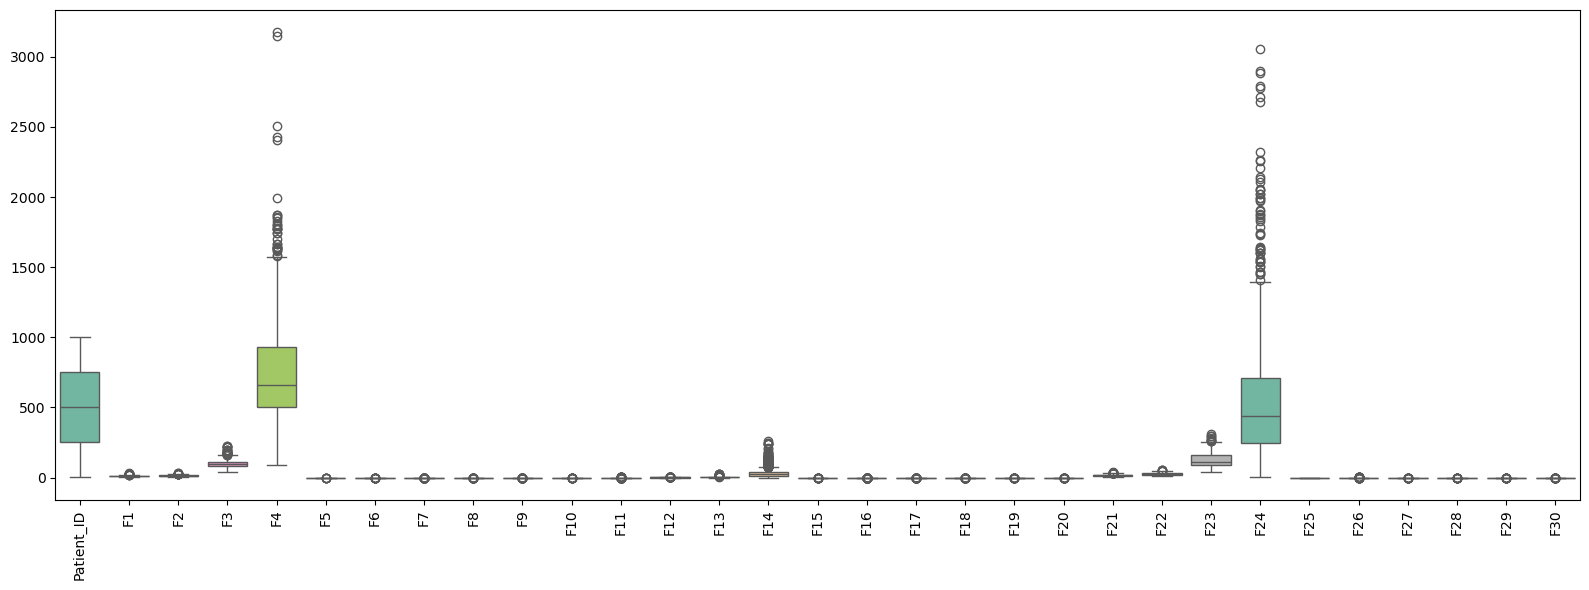

In [6]:
# outliers
plt.figure(figsize=(16,6))
plt.xticks(rotation=90) 
sns.boxplot(data=numeric_data,palette='Set2')
plt.tight_layout()
plt.show()

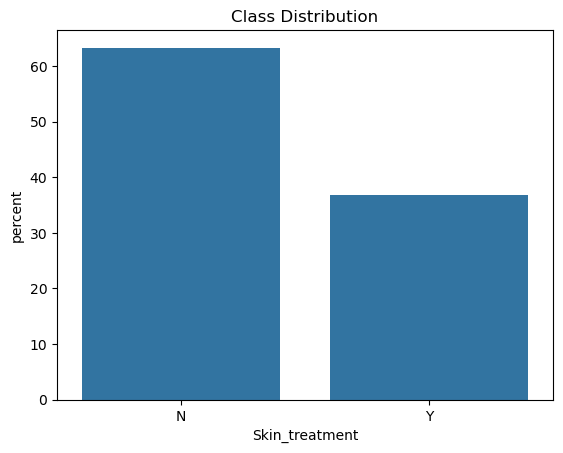

In [7]:
#Class imbalance
sns.countplot(x=data['Skin_treatment'],stat='percent')
plt.title("Class Distribution")
plt.show()

In [8]:
#Fix the defects found above and do appropriate treatment if required.
data.isna().sum()

Patient_ID        0
Skin_treatment    0
F1                1
F2                1
F3                2
F4                0
F5                2
F6                0
F7                1
F8                1
F9                1
F10               1
F11               5
F12               0
F13               0
F14               0
F15               0
F16               0
F17               0
F18               0
F19               0
F20               0
F21               0
F22               0
F23               0
F24               0
F25               0
F26               0
F27               0
F28               0
F29               0
F30               0
dtype: int64

In [9]:
for column in numeric_data.columns:
    numeric_data[column].fillna(numeric_data[column].median(),inplace=True)

In [10]:
numeric_data.isna().sum().sum()

0

In [11]:
categoric_data.isna().sum().sum()

0

In [12]:
encoder=LabelEncoder()
categoric_data['Skin_treatment'] = encoder.fit_transform(categoric_data['Skin_treatment'])

In [13]:
df = pd.concat([numeric_data, categoric_data], axis=1)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008 entries, 0 to 1007
Data columns (total 32 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Patient_ID      1008 non-null   int64  
 1   F1              1008 non-null   float64
 2   F2              1008 non-null   float64
 3   F3              1008 non-null   float64
 4   F4              1008 non-null   float64
 5   F5              1008 non-null   float64
 6   F6              1008 non-null   float64
 7   F7              1008 non-null   float64
 8   F8              1008 non-null   float64
 9   F9              1008 non-null   float64
 10  F10             1008 non-null   float64
 11  F11             1008 non-null   float64
 12  F12             1008 non-null   float64
 13  F13             1008 non-null   float64
 14  F14             1008 non-null   float64
 15  F15             1008 non-null   float64
 16  F16             1008 non-null   float64
 17  F17             1008 non-null   f

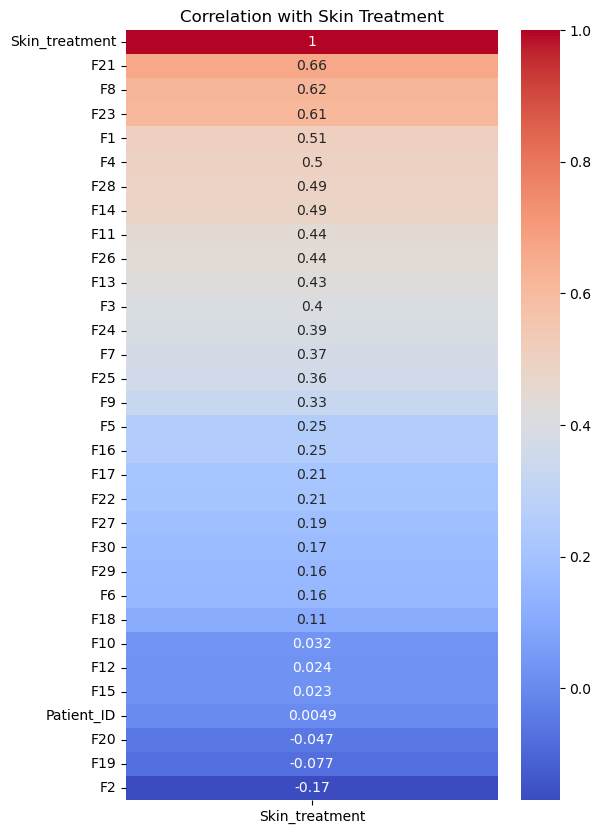

In [15]:
#Visualize the data using relevant plots. Find out the variables which are highly correlated with Target?

corr_matrix=df.corr()
#print(corr_matrix)

target_corr = corr_matrix[['Skin_treatment']].sort_values(by='Skin_treatment', ascending=False)
#print(target_corr)

plt.figure(figsize=(6, 10))
sns.heatmap(target_corr, annot=True, cmap='coolwarm')
plt.title('Correlation with Skin Treatment')
plt.show()

In [16]:
 #Do you want to exclude some variables from the model based on this analysis? What other actions will you take? 
df = df.drop(['F12', 'F10', 'F15', 'F20','Patient_ID'], axis=1)

In [17]:
#Split dataset into train and test (70:30). Are both train and test representative of the overall data? How would you ascertain this statistically? (3 marks)

y=df['Skin_treatment']
X=df.drop('Skin_treatment',axis=1)

print(y.shape)
print(X.shape)
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.3,random_state=42)

(1008,)
(1008, 26)


In [25]:
#Fit a base model and explain the reason for selecting that model. 

lr=LogisticRegression()
lr_model=lr.fit(X_train,y_train)
y_pred=lr_model.predict(X_test)


0.8448844884488449


Logistic regression is a strong baseline model due to its simplicity, interpretability, and efficiency. It provides a good starting point for evaluating and improving model performance.

In [27]:
#What is the overall Accuracy? 
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.8448844884488449


In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[164  18]
 [ 29  92]]


In [26]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87       182
           1       0.84      0.76      0.80       121

    accuracy                           0.84       303
   macro avg       0.84      0.83      0.84       303
weighted avg       0.84      0.84      0.84       303



In [32]:
from sklearn.ensemble import RandomForestClassifier

rc=RandomForestClassifier()
rc_model=rc.fit(X_train,y_train)

rcy_predict=rc_model.predict(X_test)

In [34]:
print(accuracy_score(y_test, rcy_predict))

0.9834983498349835


In [35]:
rc_cm = confusion_matrix(y_test, rcy_predict)
print(rc_cm)

[[180   2]
 [  3 118]]


In [36]:
print(classification_report(y_test,rcy_predict))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       182
           1       0.98      0.98      0.98       121

    accuracy                           0.98       303
   macro avg       0.98      0.98      0.98       303
weighted avg       0.98      0.98      0.98       303

